# 다회 지원자 세그먼트별 특성 분석
## — 지원 횟수별 지원기업수 · 북마크 · 지원 다양성 비율

---


> `05_CoreUser_Report.ipynb`(최종 통합본)의 프로필 강화 분석(11.2절)으로 이어지기 전, 지원 횟수 기준 세그먼트 특성을 먼저 탐색한 과정입니다.

**포함된 내용**: 리텐션 유저 정의 → 다회 지원자(2회 이상) 추출 → 지원횟수별 지원기업수/북마크/지원 다양성 비율 분석

**제외된 내용**: 원본에 있던 "사용자행동 비교(공고탐색·회사탐색·프로필·지원후관리)", "회사탐색 이상치" 섹션은 `multi_apply_category_df`라는, 이 노트북 어디에도 정의되지 않은 데이터프레임을 참조하고 있어 재현이 불가능했습니다. 원본(`archive/`)에도 해당 코드는 실행 불가 상태로 남아있던 것이라 함께 제외했습니다.

## 1. 환경 설정

In [1]:


import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import koreanize_matplotlib
import platform
import plotly.express as px
from sqlalchemy import create_engine

print("성공!")

성공!


## 2. 데이터 로드

### 2-1. DB 연결

In [2]:
import os
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine

# 접속 정보는 코드에 두지 않는다. 저장소 루트의 .env 에서 읽어온다.
# 최초 1회: .env.example 를 .env 로 복사한 뒤 RECRUIT_DB_URL 을 채울 것.
load_dotenv(find_dotenv(usecwd=True))
engine = create_engine(os.environ["RECRUIT_DB_URL"])


### 2-2. SQL 쿼리 실행

In [3]:
import pandas as pd
import numpy as np
import re

query = """
WITH logs AS (
    SELECT user_uuid, timestamp, URL, response_code, method
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500)

    UNION ALL

    SELECT user_uuid, timestamp, URL, response_code, method
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500)
),

step_detail_users AS (
    SELECT
        user_uuid,
        MIN(timestamp) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS step1_time
    FROM logs l
    INNER JOIN step_detail_users d
        ON l.user_uuid = d.user_uuid
       AND l.timestamp >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS step2_time
    FROM logs l
    INNER JOIN step1_users s1
        ON l.user_uuid = s1.user_uuid
       AND l.timestamp >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
),

step3_done_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS done_time
    FROM logs l
    INNER JOIN step2_users s2
        ON l.user_uuid = s2.user_uuid
       AND l.timestamp >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200
    GROUP BY l.user_uuid
),

bookmark_users AS (
    SELECT
        d.user_uuid,
        MIN(jb.cdate) AS first_bm_time,
        COUNT(DISTINCT jb.job_uuid) AS bm_cnt
    FROM step3_done_users d
    INNER JOIN JobBookmark jb
        ON d.user_uuid = jb.user_uuid
       AND jb.cdate >= d.done_time
    GROUP BY d.user_uuid
),

first_apply_users AS (
    SELECT
        d.user_uuid,
        MIN(a.cdate) AS first_apply_time,
        COUNT(*) AS apply_total,
        COUNT(DISTINCT a.job_uuid) AS apply_job_cnt
    FROM step3_done_users d
    INNER JOIN Application a
        ON d.user_uuid = a.user_uuid
       AND a.cdate >= d.done_time
    GROUP BY d.user_uuid
),

target_logs AS (
    SELECT
        l.user_uuid,
        l.timestamp,
        l.URL,
        l.response_code,
        l.method,

        d.done_time,
        fa.first_apply_time,
        fa.apply_total,
        fa.apply_job_cnt,

        bu.first_bm_time,
        COALESCE(bu.bm_cnt, 0) AS bm_cnt

    FROM logs l
    INNER JOIN step3_done_users d
        ON l.user_uuid = d.user_uuid
       AND l.timestamp >= d.done_time

    INNER JOIN first_apply_users fa
        ON l.user_uuid = fa.user_uuid

    LEFT JOIN bookmark_users bu
        ON l.user_uuid = bu.user_uuid

    WHERE l.URL IS NOT NULL
      AND TRIM(l.URL) <> ''
)

SELECT *
FROM target_logs;
"""

# 캐시파일 만들기

CACHE_FILE = "_cache/url_log_df.pkl"
REFRESH = False

if REFRESH or not os.path.exists(CACHE_FILE):
    url_log_df = pd.read_sql(query, engine)
    url_log_df.to_pickle(CACHE_FILE)
else:
    url_log_df = pd.read_pickle(CACHE_FILE)

# (데이터 보호: 원본 미리보기 출력 제거)
# url_log_df


### 2-3. 시간 컬럼 타입 변환

In [4]:
time_cols = [
    "timestamp",
    "done_time",
    "first_apply_time",
    "first_bm_time"
]

for col in time_cols:
    if col in url_log_df.columns:
        url_log_df[col] = pd.to_datetime(url_log_df[col], errors="coerce")

# (데이터 보호: 원본 미리보기 출력 제거)
# url_log_df.info()


## 3. URL 전처리

### 3-1. URL 경로 정제 (쿼리스트링·프래그먼트 제거)

In [5]:
url_log_df["url_path"] = (
    url_log_df["URL"]
    .astype(str)
    .str.split("?", n=1).str[0]
    .str.split("#", n=1).str[0]
    .str.strip()
    .str.strip("/")
    .str.lower()
)

### 3-2. URL 정규화 (normalize_url)

In [6]:
def normalize_url(url):
    if pd.isna(url):
        return "NULL_URL"
    
    url = str(url).strip().lower().strip("/")
    
    if url == "":
        return "NULL_URL"

    # 이상 URL
    if url.startswith(":uuid,"):
        return url

    # @user_id 계열
    if re.match(r"^@[^/]+/applications", url):
        return "@user_id/applications"
    if re.match(r"^@[^/]+/application", url):
        return "@user_id/application"
    if re.match(r"^@[^/]+/bookmark", url):
        return "@user_id/bookmark"
    if re.match(r"^@[^/]+/resume/step1", url):
        return "@user_id/resume/step1"
    if re.match(r"^@[^/]+/resume", url):
        return "@user_id/resume"
    if re.match(r"^@[^/]+/following", url):
        return "@user_id/following"
    if re.match(r"^@[^/]+$", url):
        return "@user_id"

    # signup
    if url.startswith("signup/detail"):
        return "signup/detail"
    if url.startswith("signup/step1/name"):
        return "signup/step1/name"
    if url.startswith("signup/step1/verify"):
        return "signup/step1/verify"
    if url.startswith("signup/step1"):
        return "signup/step1"
    if url.startswith("signup/step2/career"):
        return "signup/step2/career"
    if url.startswith("signup/step2/education"):
        return "signup/step2/education"
    if url.startswith("signup/step2"):
        return "signup/step2"
    if url.startswith("signup/step3/done"):
        return "signup/step3/done"
    if url.startswith("signup/step3/import"):
        return "signup/step3/import"
    if url.startswith("signup/step3/discover"):
        return "signup/step3/discover"
    if url.startswith("signup/step3"):
        return "signup/step3"
    if url.startswith("api/signup"):
        return "api/signup"

    # 공고 검색/탐색
    if url == "jobs":
        return "jobs"
    if url == "jobs/job_title":
        return "jobs/job_title"
    if url.startswith("api/jobs/job_title"):
        return "api/jobs/job_title"
    if url.startswith("suggest"):
        return "suggest"
    if url.startswith("search"):
        return "search"
    if url.startswith("api/search/jobs/job_title"):
        return "api/search/jobs/job_title"
    if url.startswith("api/search/specialty"):
        return "api/search/specialty"
    if url.startswith("api/search/companies"):
        return "api/search/companies"
    if url.startswith("api/search/people"):
        return "api/search/people"
    if url.startswith("api/recommend_specialty"):
        return "api/recommend_specialty"
    if url.startswith("api/jobs/widget/widget_templates"):
        return "api/jobs/widget/widget_templates"
    if url.startswith("api/jobs/collections/template"):
        return "api/jobs/collections/template"

    # 공고 상세 / 지원 절차
    if re.match(r"^jobs/[0-9]+/apply/step1", url):
        return "jobs/id/apply/step1"
    if re.match(r"^jobs/[0-9]+/apply/step2", url):
        return "jobs/id/apply/step2"
    if re.match(r"^jobs/[0-9]+/apply/step3", url):
        return "jobs/id/apply/step3"
    if re.match(r"^jobs/[0-9]+/apply/step4", url):
        return "jobs/id/apply/step4"
    if re.match(r"^jobs/[0-9]+/apply/complete", url):
        return "jobs/id/apply/complete"
    if re.match(r"^jobs/[0-9]+/applications", url):
        return "jobs/id/applications"
    if re.match(r"^jobs/[0-9]+/[^/]+$", url):
        return "jobs/id/id_title"
    if re.match(r"^jobs/[0-9]+$", url):
        return "jobs/id"

    if re.match(r"^api/jobs/[0-9]+/apply/step1", url):
        return "api/jobs/id/apply/step1"
    if re.match(r"^api/jobs/[0-9]+/apply/step2", url):
        return "api/jobs/id/apply/step2"
    if re.match(r"^api/jobs/[0-9]+/apply/step3", url):
        return "api/jobs/id/apply/step3"
    if re.match(r"^api/jobs/[0-9]+/apply/step4", url):
        return "api/jobs/id/apply/step4"
    if re.match(r"^api/jobs/[0-9]+/bookmark", url):
        return "api/jobs/id/bookmark"
    if re.match(r"^api/jobs/[0-9]+/other_jobs", url):
        return "api/jobs/id/other_jobs"
    if re.match(r"^api/jobs/[0-9]+/template_oneclick", url):
        return "api/jobs/id/template_oneclick"
    if re.match(r"^api/jobs/[0-9]+/stat/progress", url):
        return "api/jobs/id/stat/progress"
    if re.match(r"^api/jobs/[0-9]+", url):
        return "api/jobs/id"

    # 회사
    if url == "companies":
        return "companies"
    if re.match(r"^companies/[^/]+/jobs/job_title", url):
        return "companies/company_id/jobs/job_title"
    if re.match(r"^companies/[^/]+/jobs", url):
        return "companies/company_id/jobs"
    if re.match(r"^companies/[^/]+$", url):
        return "companies/company_id"

    if re.match(r"^api/companies/[^/]+/view", url):
        return "api/companies/id/view"
    if re.match(r"^api/companies/[^/]+/member_list", url):
        return "api/companies/id/member_list"
    if re.match(r"^api/companies/[^/]+/ad_stat/progress", url):
        return "api/companies/id/ad_stat/progress"
    if re.match(r"^api/companies/[^/]+", url):
        return "api/companies/id"

    # 프로필 / 이력서
    if re.match(r"^api/users/[^/]+/template", url):
        return "api/users/id/template"
    if re.match(r"^api/users/[^/]+/career", url):
        return "api/users/id/career"
    if re.match(r"^api/users/[^/]+/project", url):
        return "api/users/id/project"
    if re.match(r"^api/users/[^/]+/education", url):
        return "api/users/id/education"
    if re.match(r"^api/users/[^/]+/specialty", url):
        return "api/users/id/specialty"
    if re.match(r"^api/users/[^/]+/phone/verify", url):
        return "api/users/id/phone/verify"
    if re.match(r"^api/users/[^/]+", url):
        return "api/users/id"

    if url.startswith("api/people/template"):
        return "api/people/template"
    if url.startswith("api/project/form_data/media"):
        return "api/project/form_data/media"
    if url.startswith("api/references"):
        return "api/references"
    if re.match(r"^api/verify/education/[0-9]+", url):
        return "api/verify/education/id"
    if re.match(r"^api/verify/career/[0-9]+", url):
        return "api/verify/career/id"
    if re.match(r"^api/media/[0-9]+/form", url):
        return "api/media/id/form"

    # 지원 후 관리
    if url.startswith("api/apply_progress"):
        return "api/apply_progress"
    if re.match(r"^api/remove_application/[0-9]+", url):
        return "api/remove_application/id"
    if re.match(r"^api/application_thread_comment/[0-9]+", url):
        return "api/application_thread_comment/id"

    # 저장 / 오퍼 / 홈피드
    if url.startswith("api/jobs/user_filter"):
        return "api/jobs/user_filter/id"
    if re.match(r"^api/specialties/[0-9]+/follow_button", url):
        return "api/specialties/id/follow_button"
    if url.startswith("api/job_offer"):
        return "api/job_offer"
    if url.startswith("api/timeline"):
        return "api/timeline"
    if url.startswith("timeline"):
        return "timeline"
    if url.startswith("api/current_guided_action"):
        return "api/current_guided_action/id"

    # 사람 / 콘텐츠
    if url.startswith("people"):
        return "people"
    if re.match(r"^api/post/[0-9]+", url):
        return "api/post/id"
    if re.match(r"^api/page/[0-9]+/view", url):
        return "api/page/id/view"

    # 계정 / 공통
    if url.startswith("setting"):
        return "setting"
    if url.startswith("continue"):
        return "continue"
    if url.startswith("email_verify"):
        return "email_verify"
    if url.startswith("password_reset"):
        return "password_reset"
    if url.startswith("verify_phone"):
        return "verify_phone"
    if url.startswith("help"):
        return "help"

    return url

### 3-3. 정규화 URL 적용

In [7]:
url_log_df["normalized_url"] = url_log_df["url_path"].apply(normalize_url)

# (데이터 보호: 원본 미리보기 출력 제거)
# url_log_df[["URL", "url_path", "normalized_url"]].head()


### 3-4. 카테고리·서브카테고리 매핑

In [8]:
# 카테고리 / 서브 카테고리 가져올때 사용
# 제가 공유해 드렸던 url_refined_category_mapping.csv 저장하고 경로복사
mapping_csv_path = "_cache/url_refined_category_mapping.csv"

mapping_ref = pd.read_csv(mapping_csv_path)

mapping_ref["url"] = mapping_ref["url"].astype(str).str.strip()

mapping_df = (
    mapping_ref[["url", "category", "subcategory"]]
    .drop_duplicates()
    .rename(columns={"url": "normalized_url"})
)

url_log_df = url_log_df.merge(
    mapping_df,
    on="normalized_url",
    how="left"
)

url_log_df["category"] = url_log_df["category"].fillna("99_기타/미분류")
url_log_df["subcategory"] = url_log_df["subcategory"].fillna("미분류")

# (데이터 보호: 원본 미리보기 출력 제거)
# url_log_df.head()


### 3-5. URL별 집계 (category × subcategory × url)

In [9]:
refined_category = (
    url_log_df
    .groupby(["category", "subcategory", "normalized_url"], as_index=False)
    .agg(
        log_count=("user_uuid", "count"),
        user_count=("user_uuid", "nunique")
    )
    .rename(columns={"normalized_url": "url"})
)

total_logs = refined_category["log_count"].sum()
total_users = url_log_df["user_uuid"].nunique()

refined_category["log_ratio_total"] = (
    refined_category["log_count"] / total_logs * 100
).round(4)

refined_category["user_ratio_total"] = (
    refined_category["user_count"] / total_users * 100
).round(4)

refined_category = refined_category.sort_values(
    "user_count",
    ascending=False
).reset_index(drop=True)

refined_category.head(30)

### 3-6. 비정상 URL 제거

In [10]:
refined_category["url"] = refined_category["url"].astype(str).str.strip()

url_lower = refined_category["url"].astype(str).str.strip().str.lower()

# 1) :uuid, 로 시작하는 이상 URL
remove_uuid = url_lower.str.startswith(":uuid,")

# 2) 결측 / 파싱 실패 URL
remove_parsing_fail = url_lower.isin([
    "null_url",
    "none",
    "r",
    "api"
])

# 3) null / undefined 포함 URL
remove_null_or_undefined = (
    url_lower.str.contains("undefined", na=False) |
    url_lower.str.contains(r"(^|/|,)null($|/|,)", regex=True, na=False)
)

# 4) signup 들어간 URL 제거
remove_signup = url_lower.str.contains("signup", na=False)

remove_condition = (
    remove_uuid |
    remove_parsing_fail |
    remove_null_or_undefined |
    remove_signup
)

removed_url_df = refined_category[remove_condition].copy().reset_index(drop=True)
refined_category_clean = refined_category[~remove_condition].copy().reset_index(drop=True)

print("원본 URL 개수:", len(refined_category))
print("제거된 URL 개수:", len(removed_url_df))
print("남은 URL 개수:", len(refined_category_clean))

print("원본 log_count 합계:", refined_category["log_count"].sum())
print("제거된 log_count 합계:", removed_url_df["log_count"].sum())
print("남은 log_count 합계:", refined_category_clean["log_count"].sum())

refined_category_clean.head()

원본 URL 개수: 154
제거된 URL 개수: 14
남은 URL 개수: 140
원본 log_count 합계: 4497081
제거된 log_count 합계: 9459
남은 log_count 합계: 4487622


### 3-7. 상위 URL 필터링 (user_count 70% 이상)

In [11]:
user_count_threshold = refined_category_clean["user_count"].quantile(0.70)

top_url_df = refined_category_clean[
    refined_category_clean["user_count"] >= user_count_threshold
].copy()

top_url_df = top_url_df.sort_values(
    "user_count",
    ascending=False
).reset_index(drop=True)

print("user_count 70% 분위수 기준:", user_count_threshold)
print("선택된 URL 개수:", len(top_url_df))

top_url_df.head(30)

user_count 70% 분위수 기준: 2644.6
선택된 URL 개수: 42


## 4. 리텐션 정의 및 전처리

### 4-1. 리텐션 정의 기준

| 항목 | 기준 |
|------|------|
| 모수 | signup/step3/done 완료 후 첫 지원(Application)이 존재하는 유저 |
| 리텐션 인정 조건 | 첫 지원 시각으로부터 **24시간(RETENTION_GAP)** 이후 |
| 대상 URL | user_count 70% 분위수 이상인 상위 URL (top_url_df) |
| 분석 기간 | D+1 ~ D+90 |
| 관측 가능 여부 |  — D+N까지 관측 가능한 유저만 해당 day 모수에 포함 |
| 롤링 리텐션 정의 | D+N 이후 top URL에 **1회 이상** 재방문한 유저 비율 |


In [12]:
import pandas as pd

# 1. timestamp: timezone 있는 상태면 timezone 제거
url_log_df["timestamp"] = pd.to_datetime(
    url_log_df["timestamp"],
    errors="coerce"
)

if isinstance(url_log_df["timestamp"].dtype, pd.DatetimeTZDtype):
    url_log_df["timestamp"] = url_log_df["timestamp"].dt.tz_localize(None)


# 2. first_apply_time: 일반 datetime으로 변환
url_log_df["first_apply_time"] = pd.to_datetime(
    url_log_df["first_apply_time"],
    errors="coerce"
)

if isinstance(url_log_df["first_apply_time"].dtype, pd.DatetimeTZDtype):
    url_log_df["first_apply_time"] = url_log_df["first_apply_time"].dt.tz_localize(None)


# 3. 확인
# (데이터 보호: 원본 미리보기 출력 제거)
# print(url_log_df[["timestamp", "first_apply_time"]].dtypes)


### 4-2. 타임존 제거 및 datetime 정리

### 4-3. 첫 지원 이후 24시간 이후 로그 필터링

In [13]:
top_urls = set(top_url_df["url"])

# 시간값 없는 row 제거
valid_time_df = url_log_df.dropna(
    subset=["timestamp", "first_apply_time"]
).copy()

RETENTION_GAP = pd.Timedelta(hours=24) # 24시간 이후로 부터

after_first_apply_logs = valid_time_df[
    (valid_time_df["timestamp"] > valid_time_df["first_apply_time"] + RETENTION_GAP) &
    (valid_time_df["normalized_url"].isin(top_urls))
].copy()

retention_users = (
    after_first_apply_logs
    .groupby("user_uuid", as_index=False)
    .agg(
        first_retention_time=("timestamp", "min"),
        retention_log_count=("normalized_url", "count"),
        retention_url_count=("normalized_url", "nunique")
    )
)

# (데이터 보호: 원본 미리보기 출력 제거)
# retention_users


### 4-4. 리텐션 유저 집계

In [14]:
base_apply_users = (
    url_log_df[
        [
            "user_uuid",
            "done_time",
            "first_apply_time",
            "apply_total",
            "apply_job_cnt",
            "first_bm_time",
            "bm_cnt"
        ]
    ]
    .drop_duplicates(subset=["user_uuid"])
    .copy()
)

retention_result = base_apply_users.merge(
    retention_users,
    on="user_uuid",
    how="left"
)

retention_result["is_retained"] = retention_result["first_retention_time"].notna()

# (데이터 보호: 원본 미리보기 출력 제거)
# retention_result.head()


### 4-5. 리텐션 결과 테이블 생성

In [15]:
retention_summary = pd.DataFrame({
    "base_apply_users": [retention_result["user_uuid"].nunique()],
    "retained_users": [retention_result["is_retained"].sum()],
})

retention_summary["retention_rate"] = (
    retention_summary["retained_users"] / retention_summary["base_apply_users"] * 100
).round(2)

retention_summary

### 4-6. 전체 리텐션 요약

## 5. 다회 지원자(2회 이상 지원) 특성 분석

### 5-1. 지원 횟수별 지원기업수·북마크 수

In [16]:
# 지원 기업수 별도 쿼리
# etention_result에 merge하는 방식

query = """
WITH logs AS (
    SELECT user_uuid, timestamp, URL, response_code, method
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500)

    UNION ALL

    SELECT user_uuid, timestamp, URL, response_code, method
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500)
),

step_detail_users AS (
    SELECT
        user_uuid,
        MIN(timestamp) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS step1_time
    FROM logs l
    INNER JOIN step_detail_users d
        ON l.user_uuid = d.user_uuid
       AND l.timestamp >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS step2_time
    FROM logs l
    INNER JOIN step1_users s1
        ON l.user_uuid = s1.user_uuid
       AND l.timestamp >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
),

step3_done_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS done_time
    FROM logs l
    INNER JOIN step2_users s2
        ON l.user_uuid = s2.user_uuid
       AND l.timestamp >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200
    GROUP BY l.user_uuid
),

apply_company_summary AS (
    SELECT
        d.user_uuid,
        COUNT(*) AS apply_total_check,
        COUNT(DISTINCT a.job_uuid) AS apply_job_cnt_check,
        COUNT(DISTINCT a.company_uuid) AS apply_company_cnt
    FROM step3_done_users d
    INNER JOIN application a
        ON d.user_uuid = a.user_uuid
       AND a.cdate >= d.done_time
    GROUP BY d.user_uuid
)

SELECT *
FROM apply_company_summary;
"""

# 캐시파일 만들기

CACHE_FILE = "_cache/apply_company_df.pkl"
REFRESH = False

if REFRESH or not os.path.exists(CACHE_FILE):
    apply_company_df = pd.read_sql(query, engine)
    apply_company_df.to_pickle(CACHE_FILE)
else:
    apply_company_df = pd.read_pickle(CACHE_FILE)

# (데이터 보호: 원본 미리보기 출력 제거)
# apply_company_df



In [17]:
# retention_result에 지원 기업수 merge

retention_result = retention_result.merge(
    apply_company_df[
        ["user_uuid", "apply_company_cnt"]
    ],
    on="user_uuid",
    how="left"
)

retention_result["apply_company_cnt"] = retention_result["apply_company_cnt"].fillna(0).astype(int)

# 출력
# (데이터 보호: 원본 미리보기 출력 제거)
# retention_result.head()


In [18]:
# 리텐션 유저 중 다회 지원자 추출

multi_apply_df = retention_result[
    (retention_result["is_retained"] == True) &
    (retention_result["apply_total"] >= 2)
].copy()

print("리텐션 유저 중 다회 지원자 수:", multi_apply_df["user_uuid"].nunique())
# (데이터 보호: 원본 미리보기 출력 제거)
# multi_apply_df.head()


리텐션 유저 중 다회 지원자 수: 2609


In [19]:
# n회별 지원자 세부 분석
# 그룹화 사용하지 않음

apply_n_summary = (
    multi_apply_df
    .groupby("apply_total", as_index=False)
    .agg(
        user_cnt=("user_uuid", "nunique"),
        avg_apply=("apply_total", "mean"),
        avg_job_cnt=("apply_job_cnt", "mean"),
        median_job_cnt=("apply_job_cnt", "median"),
        avg_company_cnt=("apply_company_cnt", "mean"),
        median_company_cnt=("apply_company_cnt", "median"),
        avg_bm_cnt=("bm_cnt", "mean"),
        median_bm_cnt=("bm_cnt", "median")
    )
    .sort_values("apply_total")
)

apply_n_summary

In [20]:
# 컬럼명 한글화

apply_n_summary_view = apply_n_summary.rename(columns={
    "apply_total": "지원횟수",
    "user_cnt": "유저수",
    "avg_apply": "평균지원횟수",
    "avg_job_cnt": "평균지원공고수",
    "median_job_cnt": "중앙값지원공고수",
    "avg_company_cnt": "평균지원기업수",
    "median_company_cnt": "중앙값지원기업수",
    "avg_bm_cnt": "평균북마크수",
    "median_bm_cnt": "중앙값북마크수"
})

apply_n_summary_view

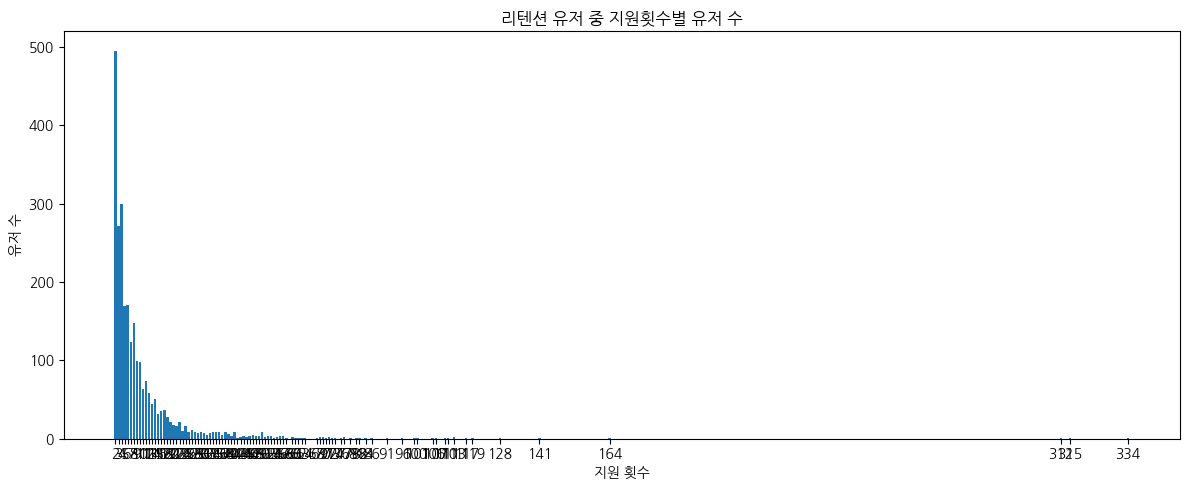

In [21]:
# 시각화 1. 지원횟수별 유저 수

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.bar(
    apply_n_summary["apply_total"],
    apply_n_summary["user_cnt"]
)

plt.title("리텐션 유저 중 지원횟수별 유저 수")
plt.xlabel("지원 횟수")
plt.ylabel("유저 수")
plt.xticks(apply_n_summary["apply_total"])

plt.tight_layout()
plt.show()



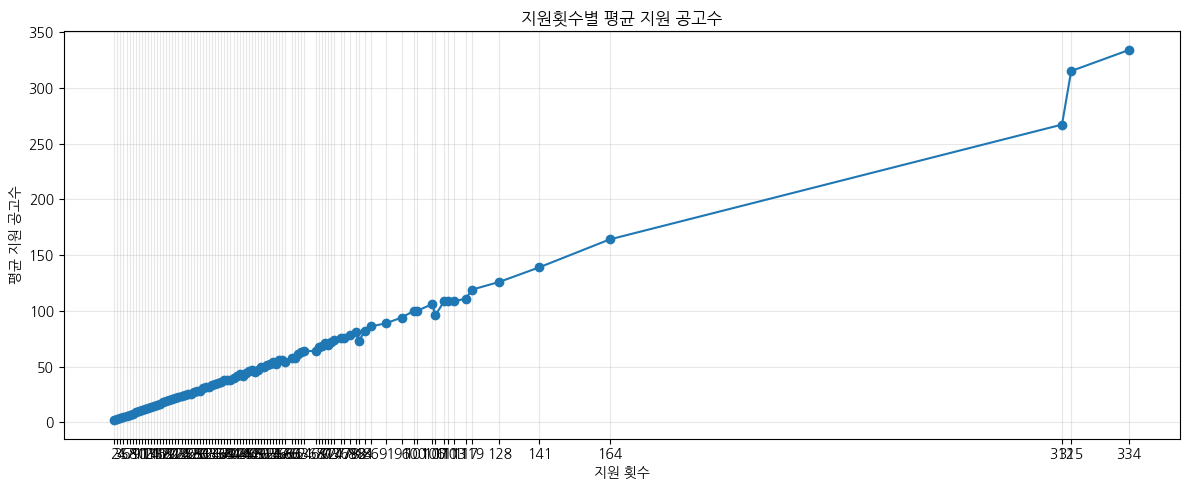

In [22]:
# 시각화 2. 지원횟수별 평균 지원 공고수

plt.figure(figsize=(12, 5))

plt.plot(
    apply_n_summary["apply_total"],
    apply_n_summary["avg_job_cnt"],
    marker="o"
)

plt.title("지원횟수별 평균 지원 공고수")
plt.xlabel("지원 횟수")
plt.ylabel("평균 지원 공고수")
plt.xticks(apply_n_summary["apply_total"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



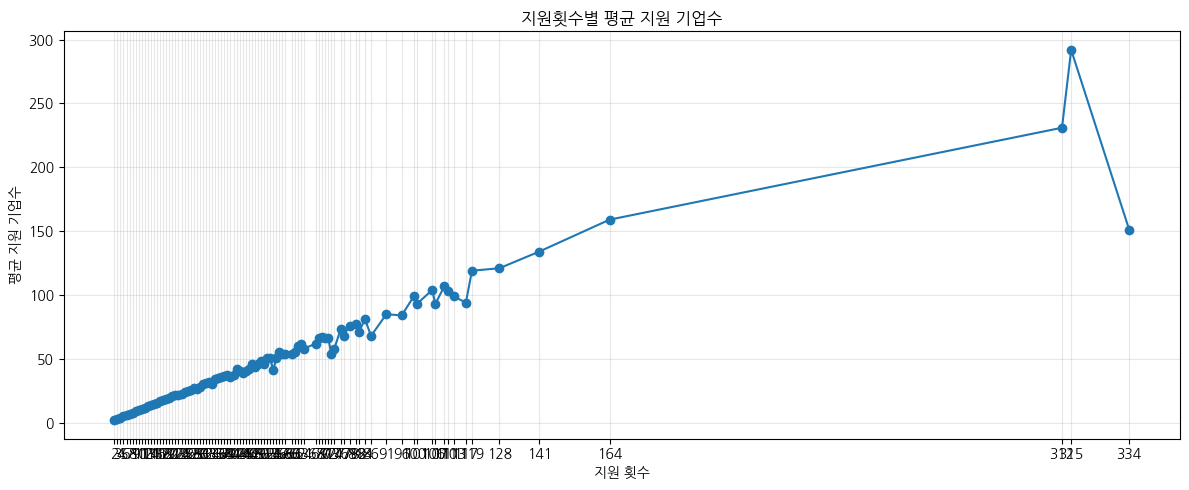

In [23]:
# 시각화 3. 지원횟수별 평균 지원 기업수

plt.figure(figsize=(12, 5))

plt.plot(
    apply_n_summary["apply_total"],
    apply_n_summary["avg_company_cnt"],
    marker="o"
)

plt.title("지원횟수별 평균 지원 기업수")
plt.xlabel("지원 횟수")
plt.ylabel("평균 지원 기업수")
plt.xticks(apply_n_summary["apply_total"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



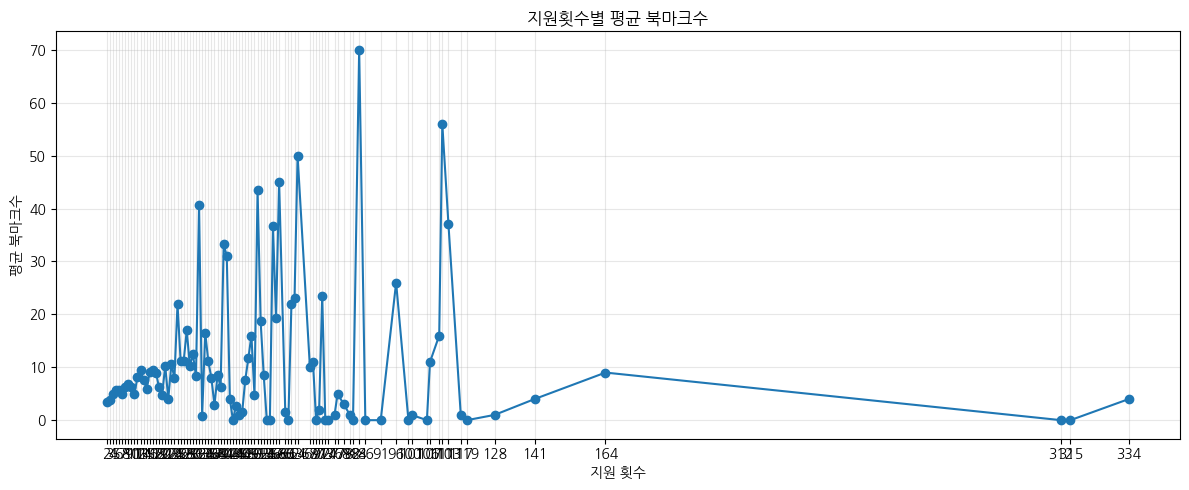

In [24]:
# 시각화 4. 지원횟수별 평균 북마크수

plt.figure(figsize=(12, 5))

plt.plot(
    apply_n_summary["apply_total"],
    apply_n_summary["avg_bm_cnt"],
    marker="o"
)

plt.title("지원횟수별 평균 북마크수")
plt.xlabel("지원 횟수")
plt.ylabel("평균 북마크수")
plt.xticks(apply_n_summary["apply_total"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [25]:
# 북마크 중앙값
multi_apply_df.groupby("apply_total").agg(
    user_cnt=("user_uuid","nunique"),
    median_bm=("bm_cnt","median")
)

In [26]:
# 시각화 5. 지원횟수별 중앙값 북마크수
median_bm_df = (
    multi_apply_df
    .groupby("apply_total", as_index=False)
    .agg(
        user_cnt=("user_uuid", "nunique"),
        median_bm=("bm_cnt", "median")
    )
)


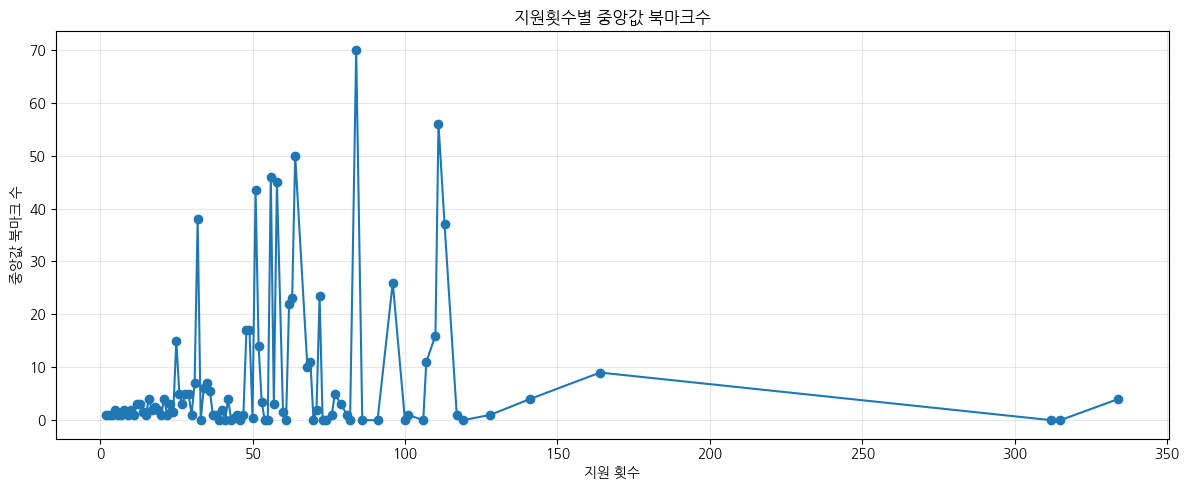

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    median_bm_df["apply_total"],
    median_bm_df["median_bm"],
    marker="o"
)

plt.title("지원횟수별 중앙값 북마크수")
plt.xlabel("지원 횟수")
plt.ylabel("중앙값 북마크 수")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [28]:
# 시각화6. 북마크 중앙값
median_bm_df = (
    multi_apply_df
    .groupby("apply_total", as_index=False)
    .agg(
        user_cnt=("user_uuid", "nunique"),
        median_bm=("bm_cnt", "median"),
        avg_bm=("bm_cnt", "mean")
    )
)

median_bm_df = median_bm_df[
    median_bm_df["user_cnt"] >= 20
]

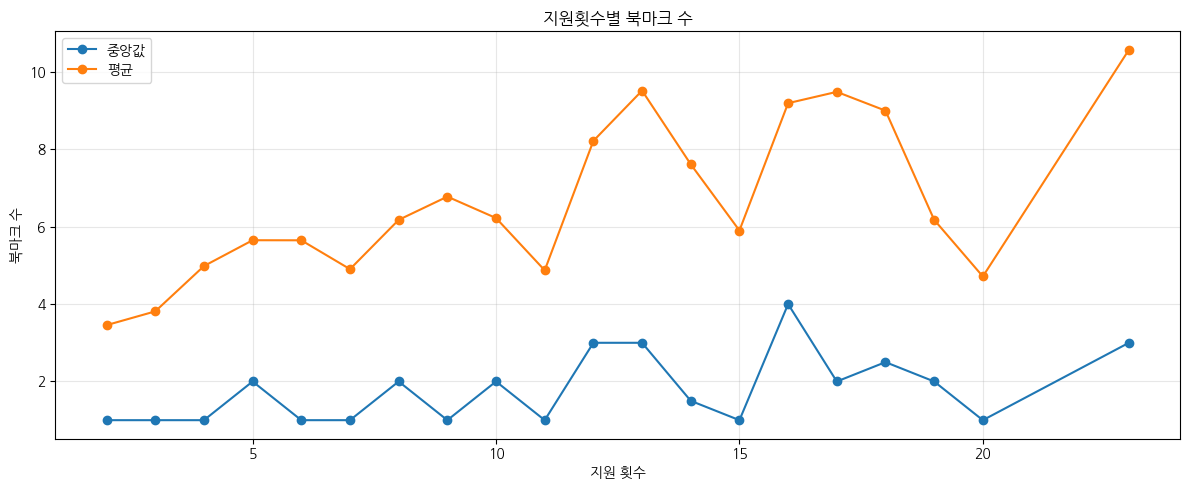

In [29]:
plt.figure(figsize=(12,5))

plt.plot(
    median_bm_df["apply_total"],
    median_bm_df["median_bm"],
    marker="o",
    label="중앙값"
)

plt.plot(
    median_bm_df["apply_total"],
    median_bm_df["avg_bm"],
    marker="o",
    label="평균"
)

plt.title("지원횟수별 북마크 수")
plt.xlabel("지원 횟수")
plt.ylabel("북마크 수")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


- 다회 지원자는 다양한 공고를 탐색하며, 북마크 사용량도 일반 유저보다 높은 경향을 보임

### 5-2. 지원 다양성 (동일 공고 반복 vs 다양한 공고 탐색)

In [30]:
# 유저당 중복지원 수 확인
# apply_total 과 apply_job_cnt 비교
multi_apply_df[
    ["apply_total","apply_job_cnt","apply_company_cnt"]
].describe()

In [31]:
# 같은 공고/같은 기업에 반복 지원하는지,
# 아니면 여러 공고/기업에 분산 지원하는지 확인
# 1에 가까울수록 다양한 공고 지원
# 0에 가까울수록 동일공고 다회 지원

multi_apply_df["job_diversity_ratio"] = (
    multi_apply_df["apply_job_cnt"] / multi_apply_df["apply_total"]
)

multi_apply_df["company_diversity_ratio"] = (
    multi_apply_df["apply_company_cnt"] / multi_apply_df["apply_total"]
)

diversity_summary = (
    multi_apply_df
    .groupby("apply_total", as_index=False)
    .agg(
        user_cnt=("user_uuid", "nunique"),
        avg_job_diversity=("job_diversity_ratio", "mean"),
        avg_company_diversity=("company_diversity_ratio", "mean")
    )
    .round(3)
    .sort_values("apply_total")
)

diversity_summary

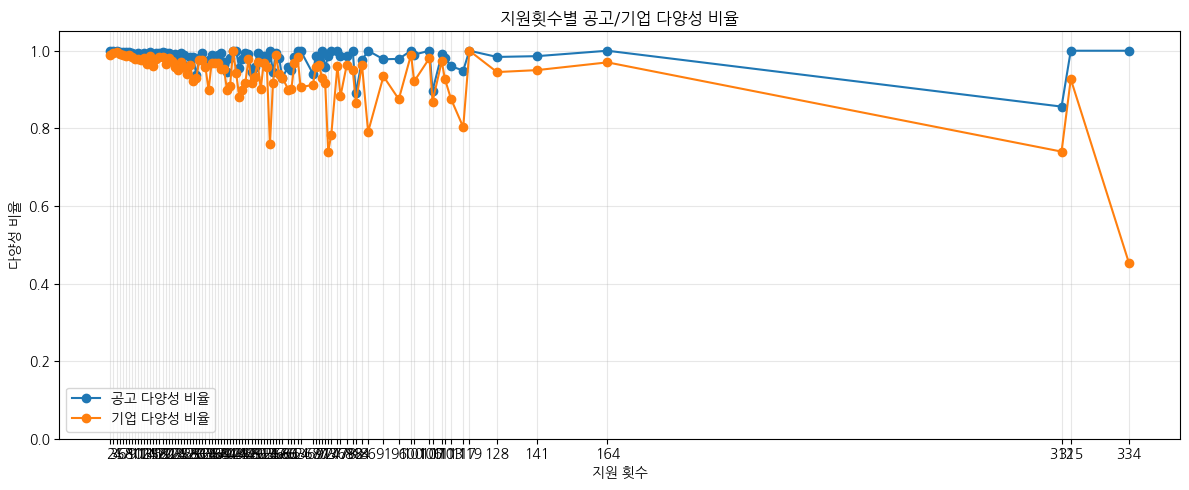

In [32]:
# 시각화 7. 지원 다양성 비율

plt.figure(figsize=(12, 5))

plt.plot(
    diversity_summary["apply_total"],
    diversity_summary["avg_job_diversity"],
    marker="o",
    label="공고 다양성 비율"
)

plt.plot(
    diversity_summary["apply_total"],
    diversity_summary["avg_company_diversity"],
    marker="o",
    label="기업 다양성 비율"
)

plt.title("지원횟수별 공고/기업 다양성 비율")
plt.xlabel("지원 횟수")
plt.ylabel("다양성 비율")
plt.xticks(diversity_summary["apply_total"])
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()



- 세 컬럼의 평균값이 거의 비슷함 = 공고10번당 다른 공고 10개에 지원, 다른 회사 10군데 지원했다는 뜻
- 다회 지원자는 같은 공고를 반복 지원하는 유저가 아니라, 다양한 공고와 다양한 기업을 적극적으로 탐색하는 유저

In [33]:
apply_n_summary_view.describe()

In [34]:
apply_n_summary_view[
    apply_n_summary_view["지원횟수"] <= 73
].tail(30)

In [35]:
apply_n_summary_view[
    apply_n_summary_view["지원횟수"] >= 30
]["유저수"].sum()

### 5-3. 지원 횟수 구간화 종합

In [36]:
# 지원횟수 1~29는 그대로
# 30회 이상은 하나의 그룹
plot_df = apply_n_summary_view.copy()

plot_df["지원횟수_구간"] = np.where(
    plot_df["지원횟수"] >= 30,
    "30",
    plot_df["지원횟수"].astype(str)
)

# 1~29회 개별, 30회 이상 통합 집계
apply_segment_summary = (
    plot_df
    .groupby("지원횟수_구간", as_index=False)
    .apply(
        lambda d: pd.Series({
            "유저수": d["유저수"].sum(),
            "평균지원횟수": np.average(d["평균지원횟수"], weights=d["유저수"]),
            "평균지원공고수": np.average(d["평균지원공고수"], weights=d["유저수"]),
            "평균지원기업수": np.average(d["평균지원기업수"], weights=d["유저수"]),
            "평균북마크수": np.average(d["평균북마크수"], weights=d["유저수"])
        })
    )
    .reset_index(drop=True)
)

# 정렬

apply_segment_summary["정렬순서"] = np.where(
    apply_segment_summary["지원횟수_구간"] == "30회 이상",
    30,
    apply_segment_summary["지원횟수_구간"].astype(int)
)

apply_segment_summary = (
    apply_segment_summary
    .sort_values("정렬순서")
    .drop(columns="정렬순서")
    .reset_index(drop=True)
)

apply_segment_summary

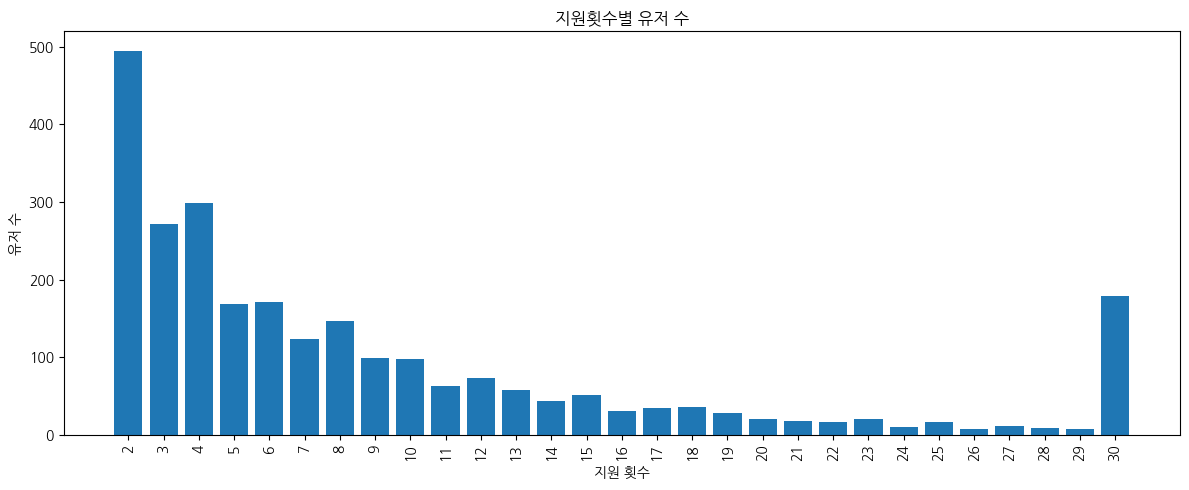

In [37]:
# 지원횟수별 유저수

plt.figure(figsize=(12,5))

plt.bar(
    apply_segment_summary["지원횟수_구간"],
    apply_segment_summary["유저수"]
)

plt.title("지원횟수별 유저 수")
plt.xlabel("지원 횟수")
plt.ylabel("유저 수")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

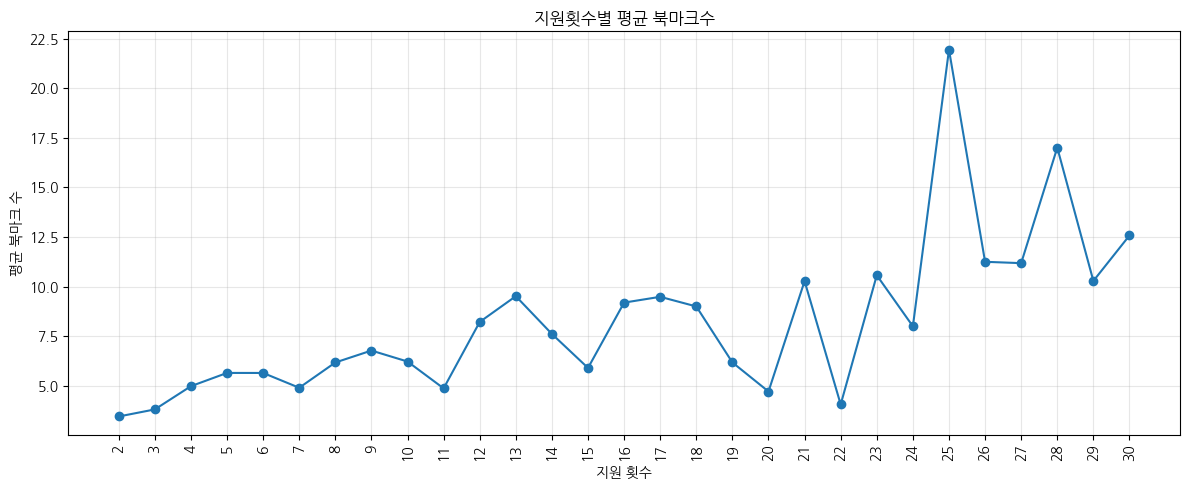

In [38]:
# 지원횟수별 평균 북마크수

plt.figure(figsize=(12,5))

plt.plot(
    apply_segment_summary["지원횟수_구간"],
    apply_segment_summary["평균북마크수"],
    marker="o"
)

plt.title("지원횟수별 평균 북마크수")
plt.xlabel("지원 횟수")
plt.ylabel("평균 북마크 수")

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

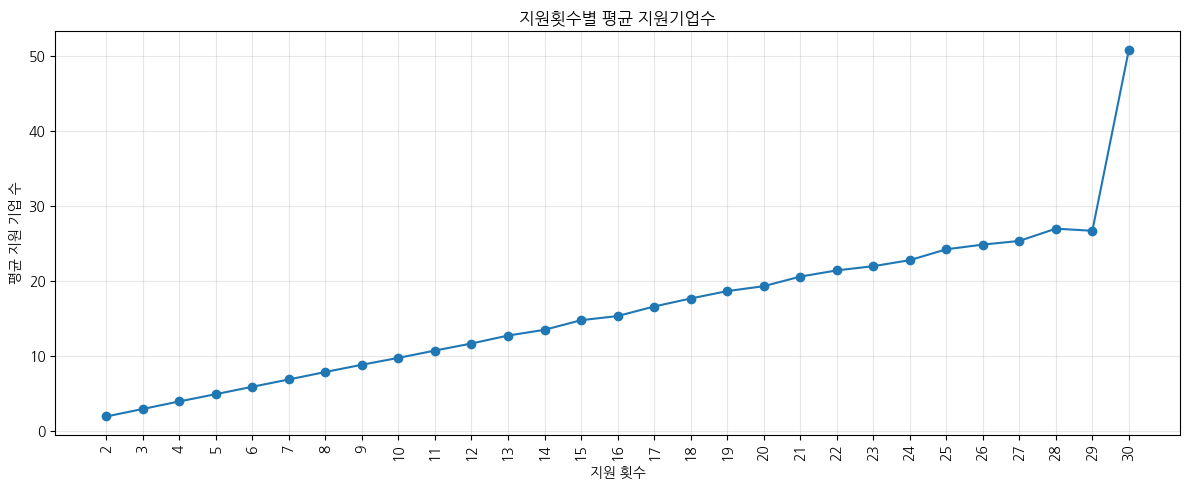

In [39]:
# 지원횟수별 평균 지원기업수

plt.figure(figsize=(12,5))

plt.plot(
    apply_segment_summary["지원횟수_구간"],
    apply_segment_summary["평균지원기업수"],
    marker="o"
)

plt.title("지원횟수별 평균 지원기업수")
plt.xlabel("지원 횟수")
plt.ylabel("평균 지원 기업 수")

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

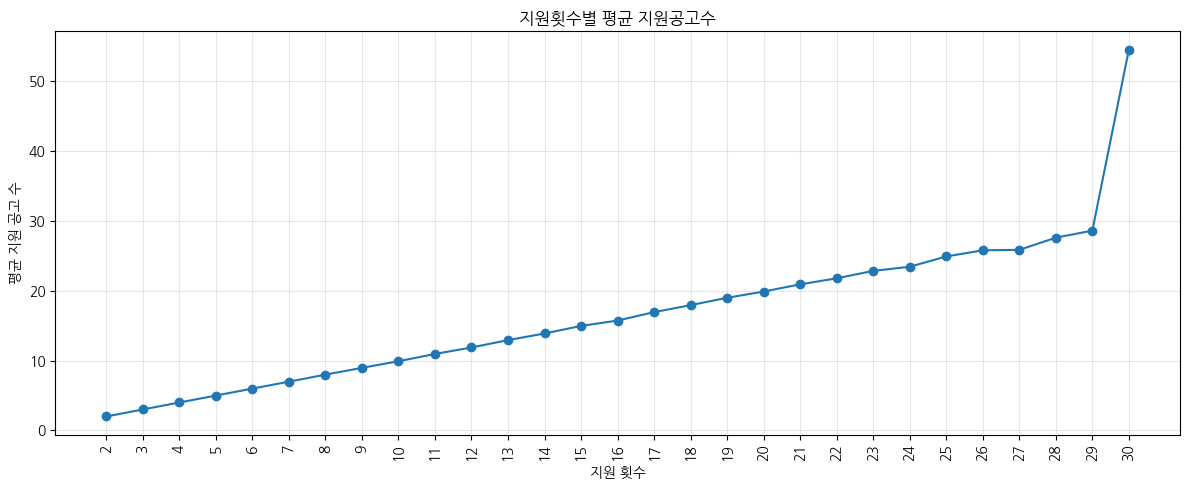

In [40]:
# 지원횟수별 평균 지원공고수

plt.figure(figsize=(12,5))

plt.plot(
    apply_segment_summary["지원횟수_구간"],
    apply_segment_summary["평균지원공고수"],
    marker="o"
)

plt.title("지원횟수별 평균 지원공고수")
plt.xlabel("지원 횟수")
plt.ylabel("평균 지원 공고 수")

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## 6. 요약

- 다회 지원자는 지원 횟수가 늘수록 지원 공고 수·지원 기업 수·북마크 수가 함께 증가하며, 다양한 공고를 폭넓게 탐색하는 경향을 보인다.
- 지원 공고 수와 지원 기업 수가 거의 비례하는 것으로 보아, 다회 지원자는 같은 공고를 반복 지원하기보다 서로 다른 공고·기업에 적극적으로 지원한다.
- 이 지원 횟수 기준 세그먼트 특성은 `05_CoreUser_Report.ipynb`의 프로필 강화 행동 분석(11.2절)으로 이어진다.
